#### Function to Check Stationarity Using Augmented Dickey-Fuller Test:

In [1]:
from statsmodels.tsa.stattools import adfuller

def dickey_fuller_result(series):
    """
    Function To Perform Augmenter Dickey-Fuller Test and Display Results.
    """
    
    result= adfuller(series.dropna())
    
    labels = ["Test Statistics", "p-Value", "No. of Lags", "No. of Observations"]
    
    output = pd.Series(result[0:4], index= labels)
    
    for key,value in result[4].items():
        output[f"Critical Value {key}"] = value
        
    print(output)
    
    print("\n")
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis.")
        print("Reject the null hypothesis.")
        print("Data has no unit root and is stationary.")
    else:
        print("Weak evidence against the null hypothesis.")
        print("Fail to reject the null hypothesis.")
        print("Data has a unit root and is non-stationary.")

#### 1) Importing Necessary Libraries:

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.tools import diff

from pmdarima import auto_arima

#### 2) Loading Data:

In [3]:
df = pd.read_csv('TradeInventories.csv', index_col= 0, parse_dates= True)

In [4]:
df.head()

,Inventories
Date,
1997-01-01,1301161
1997-02-01,1307080
1997-03-01,1303978
1997-04-01,1319740
1997-05-01,1327294


In [5]:
df.shape

(264, 1)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 264 entries, 1997-01-01 to 2018-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Inventories  264 non-null    int64
dtypes: int64(1)
memory usage: 4.1 KB


In [7]:
df.describe()

,Inventories
count,2.640000e+02
mean,1.714524e+06
std,2.121554e+05
min,1.301161e+06
25%,1.562942e+06
50%,1.687716e+06
75%,1.821569e+06
max,2.158115e+06


##### Adding Index Frequency:

In [8]:
df.index

DatetimeIndex(['1997-01-01', '1997-02-01', '1997-03-01', '1997-04-01',
               '1997-05-01', '1997-06-01', '1997-07-01', '1997-08-01',
               '1997-09-01', '1997-10-01',
               ...
               '2018-03-01', '2018-04-01', '2018-05-01', '2018-06-01',
               '2018-07-01', '2018-08-01', '2018-09-01', '2018-10-01',
               '2018-11-01', '2018-12-01'],
              dtype='datetime64[ns]', name='Date', length=264, freq=None)

In [9]:
df.index.freq = 'MS'

In [10]:
df.index

DatetimeIndex(['1997-01-01', '1997-02-01', '1997-03-01', '1997-04-01',
               '1997-05-01', '1997-06-01', '1997-07-01', '1997-08-01',
               '1997-09-01', '1997-10-01',
               ...
               '2018-03-01', '2018-04-01', '2018-05-01', '2018-06-01',
               '2018-07-01', '2018-08-01', '2018-09-01', '2018-10-01',
               '2018-11-01', '2018-12-01'],
              dtype='datetime64[ns]', name='Date', length=264, freq='MS')

##### Plotting Data:

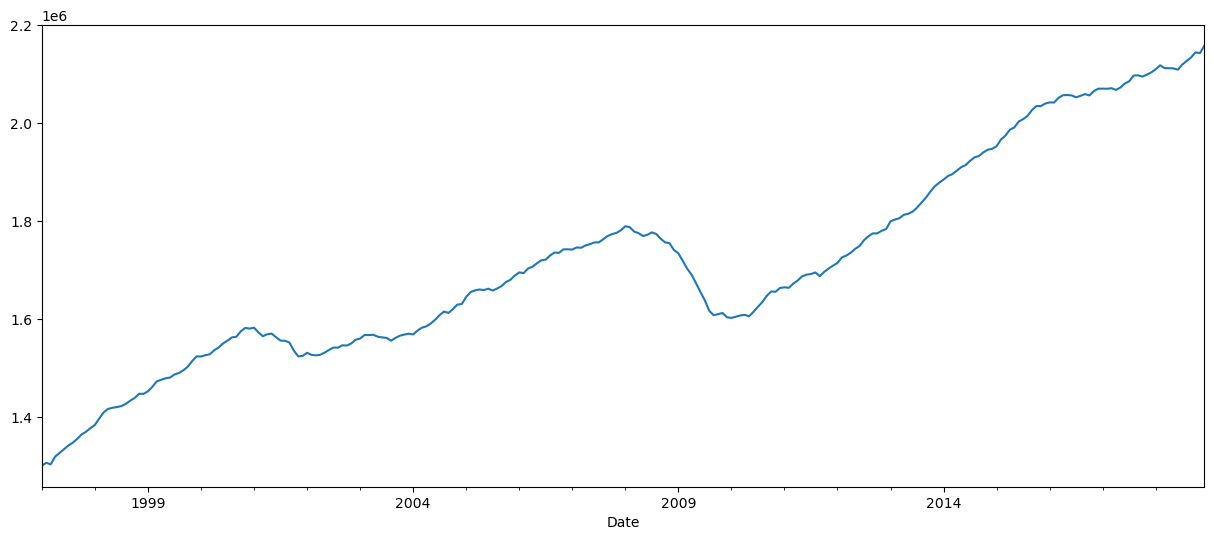

In [11]:
df['Inventories'].plot(kind= 'line', figsize= (15,6))
plt.show()

#### 3) ETS Decomposition:

In [12]:
decomp = seasonal_decompose(x= df['Inventories'],
                           model= 'additive')

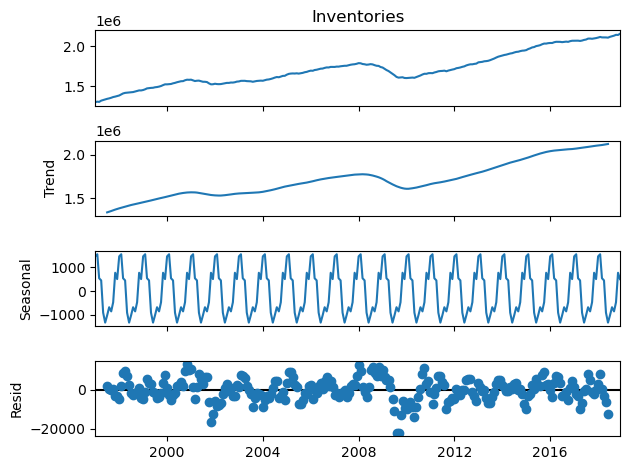

In [18]:
decomp.plot()
plt.show()

`There is some Seasonality in our data, but we will ignore it for now as it's quite small.`

#### 4) Stationarity Check:

In [19]:
dickey_fuller_result(df['Inventories'])

Test Statistics         -0.087684
p-Value                  0.950652
No. of Lags              5.000000
No. of Observations    258.000000
Critical Value 1%       -3.455953
Critical Value 5%       -2.872809
Critical Value 10%      -2.572775
dtype: float64


Weak evidence against the null hypothesis.
Fail to reject the null hypothesis.
Data has a unit root and is non-stationary.


`Series is Non-Stationary.
We have to apply Differencing.`

In [20]:
# Applying First Order Differencing:

df['Diff_1'] = diff(series= df['Inventories'], 
                   k_diff= 1)

In [21]:
df.head()

,Inventories,Diff_1
Date,,
1997-01-01,1301161,NaN
1997-02-01,1307080,5919.0
1997-03-01,1303978,-3102.0
1997-04-01,1319740,15762.0
1997-05-01,1327294,7554.0


In [22]:
# Checking Stationarity of First Order Differenced Data:

dickey_fuller_result(df['Diff_1'])

Test Statistics         -3.412249
p-Value                  0.010548
No. of Lags              4.000000
No. of Observations    258.000000
Critical Value 1%       -3.455953
Critical Value 5%       -2.872809
Critical Value 10%      -2.572775
dtype: float64


Strong evidence against the null hypothesis.
Reject the null hypothesis.
Data has no unit root and is stationary.


`First Ordered Differenced Data is Stationary (Upto 95% Confidence).`

#### 5) ACF and PACF Plots for Deciding p and q for ARIMA Model:

A <strong>PACF Plot</strong> can reveal recommended AR(p) orders, and an <strong>ACF Plot</strong> can do the same for MA(q) orders.<br>

https://people.duke.edu/~rnau/411arim3.htm

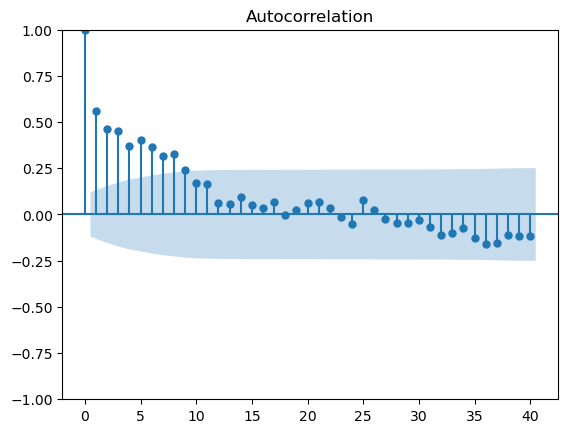

In [31]:
plot_acf(x= df['Diff_1'].dropna(), lags= 40);

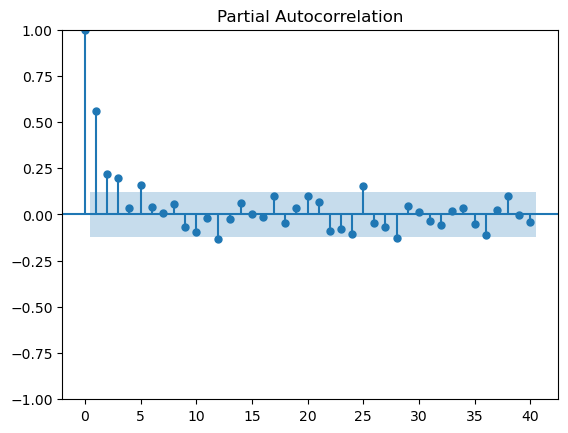

In [33]:
plot_pacf(x= df['Diff_1'].dropna(), lags= 40, method= 'ywm');

Finding $p$ (from PACF):
- Lag 1: There is a huge significant spike (approx 0.6).
- Lag 2: There is a smaller spike (approx 0.2), but it is still outside the blue "insignificance" zone.
- Lag 3+: The bars drop inside the blue zone (they become noise).
- Conclusion: The "Cut-off" happens after Lag 2.
    - Conservative choice: $p = 1$ (Start simple).
    - Aggressive choice: $p = 2$ (Capture that second spike).

Finding $q$ (from ACF): 
- Since the plot decays (tails off) rather than cutting off sharply at lag 1 or 2, we generally assume there is no MA term driving the "cut-off".
- Conclusion: $q = 0$.

##### Using PMDARIMA to Decide p, d, and q for ARIMA Model:

In [38]:
model = auto_arima(y= df['Inventories'],
                  start_p= 0,
                  start_q= 0,
                   max_p= 3,
                   max_q= 3,
                  seasonal= False,
                  trace= True)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=5348.037, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=5399.843, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=5350.241, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=5409.217, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=5378.835, Time=0.21 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.499 seconds


In [39]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  264
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -2672.018
Date:                Thu, 18 Dec 2025   AIC                           5348.037
Time:                        18:40:47   BIC                           5355.181
Sample:                    01-01-1997   HQIC                          5350.908
                         - 12-01-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   3258.3802    470.991      6.918      0.000    2335.255    4181.506
sigma2       3.91e+07   2.95e+06     13.250      0.000    3.33e+07    4.49e+07
===================================================================================
Ljung-Box (L1) (Q):                  82.61   Jarque-Bera (JB):               100.74
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.86   Skew:                            -1.15
Prob(H) (two-sided):                  0.48   Kurtosis:                         4.98
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

`p= 1 or 2 according to PACF plot and 0 according to PMDARIMA.`

`q= 0 according to both ACF plot and PMDARIMA.`

`d= 1 (First Order Differencing for Stationarity).`

`Since auto_arima model failed the diagnostic test (Prob(Q)=0), we should override the automation and decide p,d,q values from plots.`

#### 6) Train Test Split:

In [40]:
len(df)

264

In [41]:
train_data = df[:252]
test_data = df[252:]
print(train_data.shape, test_data.shape)

(252, 2) (12, 2)


#### 7) ARIMA Model 1: Order (0,1,0):

In [43]:
model1 = ARIMA(endog= train_data['Inventories'],
              order = (0,1,0))

result = model1.fit()

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            Inventories   No. Observations:                  252
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -2579.217
Date:                Thu, 18 Dec 2025   AIC                           5160.434
Time:                        18:46:34   BIC                           5163.959
Sample:                    01-01-1997   HQIC                          5161.852
                         - 12-01-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      4.911e+07   4.75e+06     10.330      0.000    3.98e+07    5.84e+07
===================================================================================
Ljung-Box (L1) (Q):                  87.24   Jarque-Bera (JB):               105.61
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.12   Skew:                            -1.20
Prob(H) (two-sided):                  0.62   Kurtosis:                         5.09
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [44]:
# Predictions on Test Data:

start = len(train_data)
end = len(test_data) + len(train_data) - 1
print(start, end)

252 263


In [46]:
preds = result.predict(start= start,
                      end= end,
                      dynamic= False)

In [47]:
preds

2018-01-01    2103751.0
2018-02-01    2103751.0
2018-03-01    2103751.0
2018-04-01    2103751.0
2018-05-01    2103751.0
2018-06-01    2103751.0
2018-07-01    2103751.0
2018-08-01    2103751.0
2018-09-01    2103751.0
2018-10-01    2103751.0
2018-11-01    2103751.0
2018-12-01    2103751.0
Freq: MS, Name: predicted_mean, dtype: float64

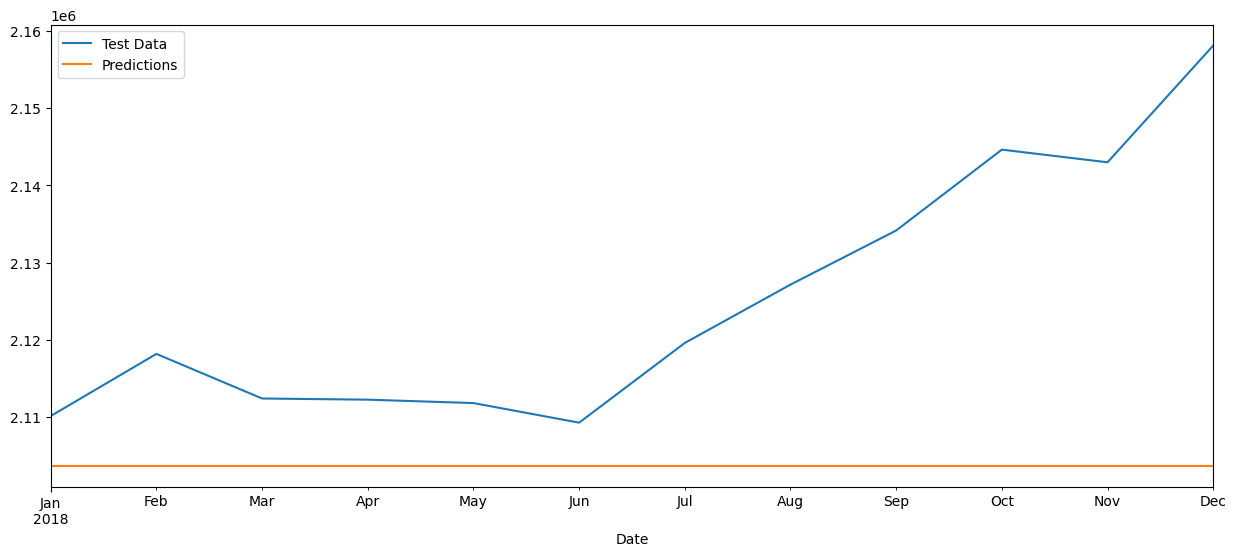

In [49]:
# Plotting Test Data and Predictions:

test_data['Inventories'].plot(kind= 'line', figsize= (15,6), label= 'Test Data', legend= True)
preds.plot(kind= 'line', figsize= (15,6), label= 'Predictions', legend= True)
plt.show()

#### 8) ARIMA Model 2: Order (1,1,0):

In [51]:
model2 = ARIMA(endog= train_data['Inventories'],
              order = (1,1,0))

result = model2.fit()

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            Inventories   No. Observations:                  252
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -2604.050
Date:                Thu, 18 Dec 2025   AIC                           5212.101
Time:                        18:56:07   BIC                           5219.152
Sample:                    01-01-1997   HQIC                          5214.938
                         - 12-01-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0099      0.003      3.010      0.003       0.003       0.016
sigma2      2.711e+07   6.43e-13   4.21e+19      0.000    2.71e+07    2.71e+07
===================================================================================
Ljung-Box (L1) (Q):                  85.76   Jarque-Bera (JB):                96.61
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.11   Skew:                            -1.16
Prob(H) (two-sided):                  0.63   Kurtosis:                         4.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.02e+36. Standard errors may be unstable.
"""

In [52]:
# Predictions on Test Data:

preds = result.predict(start= start,
                      end= end,
                      dynamic= False)

In [53]:
preds

2018-01-01    2.103797e+06
2018-02-01    2.103797e+06
2018-03-01    2.103797e+06
2018-04-01    2.103797e+06
2018-05-01    2.103797e+06
2018-06-01    2.103797e+06
2018-07-01    2.103797e+06
2018-08-01    2.103797e+06
2018-09-01    2.103797e+06
2018-10-01    2.103797e+06
2018-11-01    2.103797e+06
2018-12-01    2.103797e+06
Freq: MS, Name: predicted_mean, dtype: float64

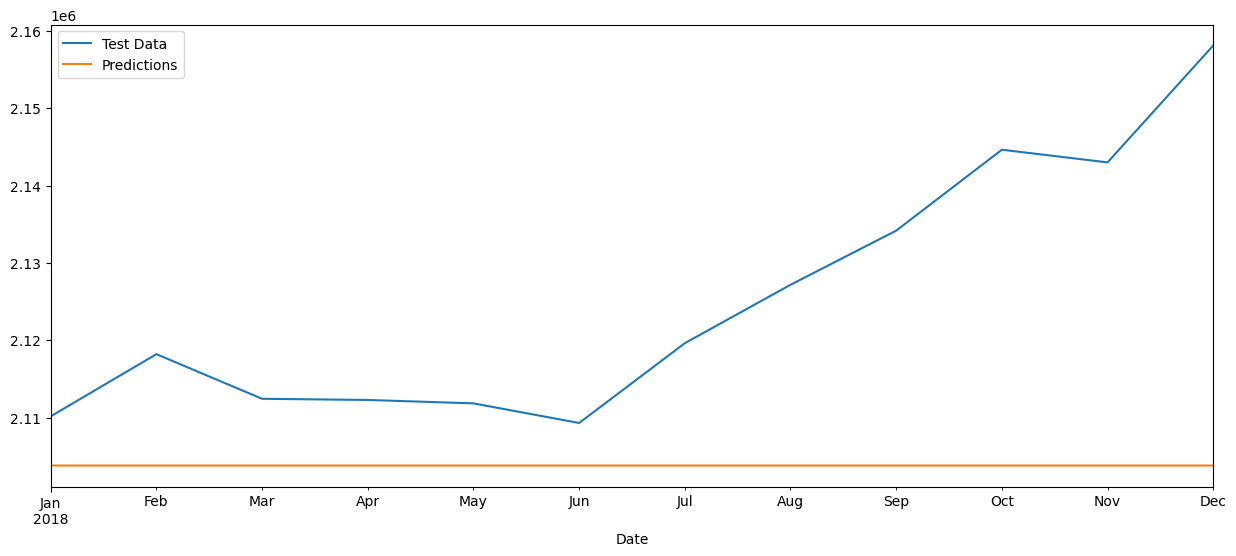

In [54]:
# Plotting Test Data and Predictions:

test_data['Inventories'].plot(kind= 'line', figsize= (15,6), label= 'Test Data', legend= True)
preds.plot(kind= 'line', figsize= (15,6), label= 'Predictions', legend= True)
plt.show()

#### 9) ARIMA Model 2: Order (1,1,1):

In [57]:
model3 = ARIMA(endog= train_data['Inventories'],
              order = (1,1,1))

result = model3.fit()

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            Inventories   No. Observations:                  252
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2567.209
Date:                Thu, 18 Dec 2025   AIC                           5140.418
Time:                        19:01:18   BIC                           5150.994
Sample:                    01-01-1997   HQIC                          5144.674
                         - 12-01-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.002    423.615      0.000       0.995       1.005
ma.L1         -0.9998      0.019    -52.970      0.000      -1.037      -0.963
sigma2       2.77e+07   5.02e-11   5.52e+17      0.000    2.77e+07    2.77e+07
===================================================================================
Ljung-Box (L1) (Q):                  87.23   Jarque-Bera (JB):               102.84
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.90   Skew:                            -1.19
Prob(H) (two-sided):                  0.64   Kurtosis:                         5.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 6.7e+32. Standard errors may be unstable.
"""

In [58]:
# Predictions on Test Data:

preds = result.predict(start= start,
                      end= end,
                      dynamic= False)

In [59]:
preds

2018-01-01    2.105745e+06
2018-02-01    2.107740e+06
2018-03-01    2.109734e+06
2018-04-01    2.111728e+06
2018-05-01    2.113722e+06
2018-06-01    2.115716e+06
2018-07-01    2.117711e+06
2018-08-01    2.119705e+06
2018-09-01    2.121699e+06
2018-10-01    2.123693e+06
2018-11-01    2.125687e+06
2018-12-01    2.127681e+06
Freq: MS, Name: predicted_mean, dtype: float64

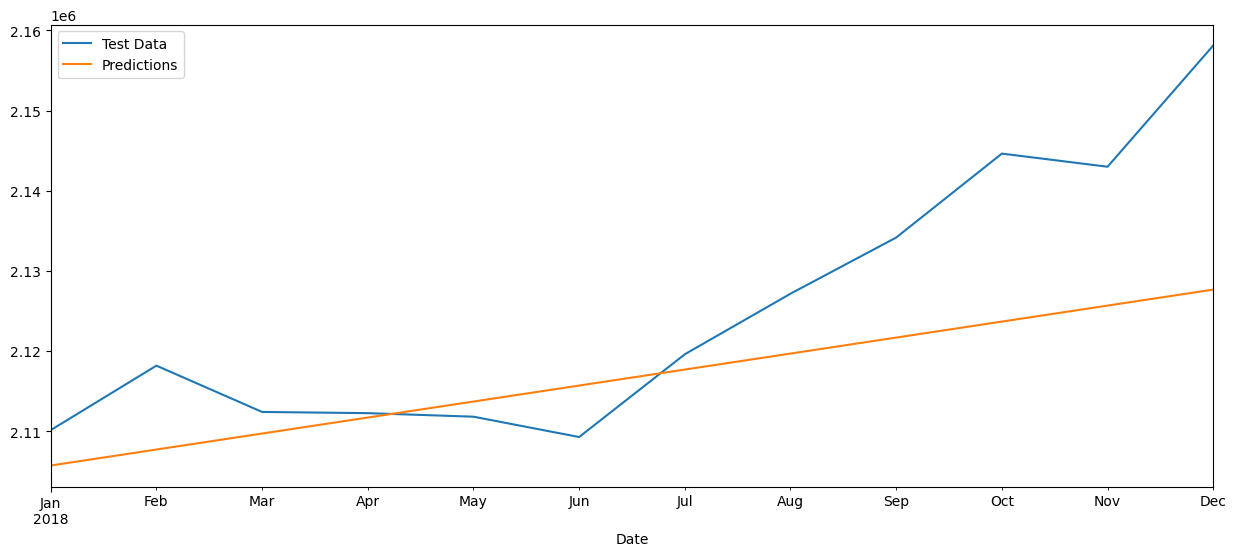

In [60]:
# Plotting Test Data and Predictions:

test_data['Inventories'].plot(kind= 'line', figsize= (15,6), label= 'Test Data', legend= True)
preds.plot(kind= 'line', figsize= (15,6), label= 'Predictions', legend= True)
plt.show()

`Conclusion: Without introducing Seasonality in Predictive Models, Models fails to capture patterns in Data.`